In [1]:
# ================================
# IMPORTS & CONFIGURATION
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score)
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA

# For handling imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# For genetic algorithm
from sklearn.base import BaseEstimator, TransformerMixin
import random

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)

# ================================
# A. DATA PREPROCESSING & CLEANING
# ================================

class DataPreprocessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='median')
        self.label_encoders = {}
        self.onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.categorical_cols = None
        self.numerical_cols = None

    def load_and_preprocess(self, filepath=None):
        """
        Load and preprocess the hotel booking dataset
        """
        if filepath:
            df = pd.read_csv(filepath)
        else:
            # Create sample data if no file provided
            df = self.create_sample_data()

        print(f"Original data shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # 1. Handle missing values
        df = self.handle_missing_values(df)

        # 2. Fix incorrect data types
        df = self.fix_data_types(df)

        # 3. Remove duplicates
        df = self.remove_duplicates(df)

        # 4. Handle outliers
        df = self.handle_outliers(df)

        # 5. Convert categorical to numerical
        df = self.encode_categorical(df)

        # 6. Convert dates to usable features
        df = self.process_dates(df)

        print(f"After preprocessing shape: {df.shape}")
        return df

    def create_sample_data(self):
        """Create sample hotel booking data for demonstration"""
        np.random.seed(42)
        n_samples = 10000

        data = {
            'hotel': np.random.choice(['City Hotel', 'Resort Hotel'], n_samples),
            'lead_time': np.random.randint(0, 400, n_samples),
            'arrival_date_year': np.random.choice([2017, 2018, 2019], n_samples),
            'arrival_date_month': np.random.choice(['January', 'February', 'March', 'April',
                                                   'May', 'June', 'July', 'August',
                                                   'September', 'October', 'November', 'December'], n_samples),
            'arrival_date_week_number': np.random.randint(1, 53, n_samples),
            'arrival_date_day_of_month': np.random.randint(1, 32, n_samples),
            'stays_in_weekend_nights': np.random.randint(0, 5, n_samples),
            'stays_in_week_nights': np.random.randint(0, 15, n_samples),
            'adults': np.random.choice([1, 2, 3, 4], n_samples, p=[0.2, 0.6, 0.15, 0.05]),
            'children': np.random.choice([0, 1, 2, 3], n_samples, p=[0.7, 0.2, 0.08, 0.02]),
            'babies': np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
            'meal': np.random.choice(['BB', 'HB', 'FB', 'SC'], n_samples, p=[0.7, 0.1, 0.1, 0.1]),
            'country': np.random.choice(['PRT', 'GBR', 'FRA', 'ESP', 'DEU'], n_samples),
            'market_segment': np.random.choice(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO'], n_samples),
            'distribution_channel': np.random.choice(['Direct', 'Corporate', 'TA/TO'], n_samples),
            'is_repeated_guest': np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),
            'previous_cancellations': np.random.poisson(0.1, n_samples),
            'previous_bookings_not_canceled': np.random.poisson(0.5, n_samples),
            'reserved_room_type': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_samples),
            'assigned_room_type': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_samples),
            'booking_changes': np.random.randint(0, 5, n_samples),
            'deposit_type': np.random.choice(['No Deposit', 'Non Refund', 'Refundable'], n_samples, p=[0.8, 0.15, 0.05]),
            'days_in_waiting_list': np.random.poisson(2, n_samples),
            'customer_type': np.random.choice(['Transient', 'Contract', 'Group'], n_samples, p=[0.8, 0.15, 0.05]),
            'adr': np.random.uniform(0, 300, n_samples),
            'required_car_parking_spaces': np.random.choice([0, 1, 2], n_samples, p=[0.9, 0.08, 0.02]),
            'total_of_special_requests': np.random.randint(0, 6, n_samples),
            'reservation_status_date': pd.date_range('2017-01-01', periods=n_samples, freq='D'),
            'is_canceled': np.random.choice([0, 1], n_samples, p=[0.6, 0.4])  # Target variable
        }

        df = pd.DataFrame(data)

        # Add some missing values
        df.loc[df.sample(frac=0.1).index, 'children'] = np.nan
        df.loc[df.sample(frac=0.05).index, 'country'] = np.nan
        df.loc[df.sample(frac=0.03).index, 'agent'] = np.nan

        return df

    def handle_missing_values(self, df):
        """Handle missing values in the dataset"""
        print("\n1. Handling missing values...")
        print(f"Missing values before:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

        # Fill numerical columns with median
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        for col in numerical_cols:
            if df[col].isnull().sum() > 0:
                df[col] = df[col].fillna(df[col].median())

        # Fill categorical columns with mode
        categorical_cols = df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            if df[col].isnull().sum() > 0:
                df[col] = df[col].fillna(df[col].mode()[0])

        print(f"Missing values after:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")
        return df

    def fix_data_types(self, df):
        """Fix incorrect data types"""
        print("\n2. Fixing data types...")

        # Convert date columns to datetime
        date_columns = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).apply(lambda x: x.str.contains(r'\d{4}-\d{2}-\d{2}').any())]

        for col in date_columns:
            try:
                df[col] = pd.to_datetime(df[col])
                print(f"Converted {col} to datetime")
            except:
                pass

        return df

    def remove_duplicates(self, df):
        """Remove duplicate rows"""
        print("\n3. Removing duplicates...")
        initial_rows = len(df)
        df = df.drop_duplicates()
        final_rows = len(df)
        print(f"Removed {initial_rows - final_rows} duplicate rows")
        return df

    def handle_outliers(self, df, method='IQR'):
        """Handle outliers using IQR method"""
        print("\n4. Handling outliers...")

        numerical_cols = df.select_dtypes(include=[np.number]).columns

        for col in numerical_cols:
            if col not in ['is_canceled', 'is_repeated_guest']:  # Skip binary columns
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1

                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                # Cap outliers
                df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
                df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

        print("Outliers handled using IQR method")
        return df

    def encode_categorical(self, df):
        """Convert categorical values to numerical"""
        print("\n5. Encoding categorical variables...")

        # Label encoding for binary categorical
        binary_cols = [col for col in df.select_dtypes(include=['object']).columns
                      if df[col].nunique() == 2]

        for col in binary_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.label_encoders[col] = le
            print(f"Label encoded: {col}")

        # One-hot encoding for multi-categorical (with few categories)
        multi_cols = [col for col in df.select_dtypes(include=['object']).columns
                     if df[col].nunique() > 2 and df[col].nunique() < 10]

        if multi_cols:
            df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
            print(f"One-hot encoded: {multi_cols}")

        # For columns with many categories, use frequency encoding
        many_cat_cols = [col for col in df.select_dtypes(include=['object']).columns
                        if df[col].nunique() >= 10]

        for col in many_cat_cols:
            freq = df[col].value_counts(normalize=True)
            df[col + '_freq'] = df[col].map(freq)
            df = df.drop(col, axis=1)
            print(f"Frequency encoded: {col}")

        return df

    def process_dates(self, df):
        """Convert dates to usable features"""
        print("\n6. Processing dates...")

        # Find date columns
        date_cols = df.select_dtypes(include=['datetime64']).columns

        for col in date_cols:
            # Extract features from dates
            df[f'{col}_year'] = df[col].dt.year
            df[f'{col}_month'] = df[col].dt.month
            df[f'{col}_day'] = df[col].dt.day
            df[f'{col}_dayofweek'] = df[col].dt.dayofweek
            df[f'{col}_quarter'] = df[col].dt.quarter
            df[f'{col}_is_weekend'] = (df[col].dt.dayofweek >= 5).astype(int)

            # Drop original date column
            df = df.drop(col, axis=1)
            print(f"Processed date column: {col}")

        # If no datetime columns, check for date-like string columns
        if date_cols.empty: # FIX: Changed `if not date_cols:` to `if date_cols.empty:`
            date_like_cols = [col for col in df.select_dtypes(include=['object']).columns
                            if any(term in col.lower() for term in ['date', 'time', 'year', 'month'])]

            for col in date_like_cols:
                try:
                    df[col] = pd.to_datetime(df[col])
                    df[f'{col}_year'] = df[col].dt.year
                    df[f'{col}_month'] = df[col].dt.month
                    df = df.drop(col, axis=1)
                    print(f"Processed date-like column: {col}")
                except:
                    pass

        return df

In [2]:
# ================================
# B. EXPLORATORY DATA ANALYSIS (EDA)
# ================================

class EDAVisualizer:
    def __init__(self):
        self.figure_counter = 1

    def generate_eda(self, df, target_col='is_canceled'):
        """Generate comprehensive EDA visualizations"""
        print("\n" + "="*50)
        print("EXPLORATORY DATA ANALYSIS (EDA)")
        print("="*50)

        self.figure_counter = 1

        # 1. Distribution of cancellations
        self.plot_cancellation_distribution(df, target_col)

        # 2. Booking trends
        self.plot_booking_trends(df)

        # 3. ADR vs Cancellations
        self.plot_adr_vs_cancellations(df, target_col)

        # 4. Correlation heatmap
        self.plot_correlation_heatmap(df, target_col)

        # 5. Lead time analysis
        self.plot_lead_time_analysis(df, target_col)

        # 6. Categorical plots
        self.plot_categorical_distributions(df, target_col)

        plt.tight_layout()
        plt.show()

    def plot_cancellation_distribution(self, df, target_col):
        """Plot distribution of cancellations"""
        plt.figure(self.figure_counter, figsize=(10, 6))
        self.figure_counter += 1

        cancellation_counts = df[target_col].value_counts()
        colors = ['#2ecc71', '#e74c3c']

        plt.subplot(1, 2, 1)
        bars = plt.bar(['Not Canceled', 'Canceled'], cancellation_counts, color=colors, alpha=0.8)
        plt.title('Distribution of Cancellations', fontsize=14, fontweight='bold')
        plt.ylabel('Count')

        # Add percentage labels
        total = sum(cancellation_counts)
        for i, (bar, count) in enumerate(zip(bars, cancellation_counts)):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + total*0.01,
                    f'{count:,}\n({count/total:.1%})', ha='center', va='bottom')

        plt.subplot(1, 2, 2)
        plt.pie(cancellation_counts, labels=['Not Canceled', 'Canceled'],
                colors=colors, autopct='%1.1f%%', startangle=90)
        plt.title('Cancellation Percentage', fontsize=14, fontweight='bold')

        plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')

        print("\nINSIGHT 1: Cancellation Distribution")
        print(f"- Cancellation rate: {cancellation_counts[1]/total:.1%}")
        print(f"- Data is {'balanced' if cancellation_counts[1]/total > 0.3 else 'imbalanced'}")
        print(f"- This affects model selection and evaluation metrics")

    def plot_booking_trends(self, df):
        """Plot booking trends by month and week"""
        plt.figure(self.figure_counter, figsize=(14, 6))
        self.figure_counter += 1

        # Check for month column
        month_cols = [col for col in df.columns if 'month' in col.lower()]

        if month_cols:
            month_col = month_cols[0]
            if df[month_col].dtype in ['int64', 'float64']:
                plt.subplot(1, 2, 1)
                monthly_bookings = df[month_col].value_counts().sort_index()
                months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

                # Map numeric months to names
                monthly_series = pd.Series(0, index=range(1, 13))
                monthly_series.update(monthly_bookings)

                plt.bar(range(1, 13), monthly_series, color='steelblue', alpha=0.8)
                plt.xticks(range(1, 13), months[:len(monthly_series)], rotation=45)
                plt.title('Monthly Booking Trends', fontsize=14, fontweight='bold')
                plt.xlabel('Month')
                plt.ylabel('Number of Bookings')

        # Check for week column
        week_cols = [col for col in df.columns if 'week' in col.lower()]

        if week_cols:
            week_col = week_cols[0]
            plt.subplot(1, 2, 2)
            weekly_bookings = df[week_col].value_counts().sort_index()

            plt.plot(weekly_bookings.index, weekly_bookings.values,
                    marker='o', linewidth=2, color='darkorange')
            plt.fill_between(weekly_bookings.index, weekly_bookings.values,
                           alpha=0.3, color='darkorange')
            plt.title('Weekly Booking Trends', fontsize=14, fontweight='bold')
            plt.xlabel('Week Number')
            plt.ylabel('Number of Bookings')
            plt.grid(True, alpha=0.3)

        plt.suptitle('Booking Trends Analysis', fontsize=16, fontweight='bold')

        print("\nINSIGHT 2: Booking Trends")
        print("- Peak booking seasons can be identified from monthly trends")
        print("- Weekly patterns may show business vs leisure travel patterns")
        print("- Seasonal trends important for demand forecasting")

    def plot_adr_vs_cancellations(self, df, target_col):
        """Plot relationship between ADR and cancellations"""
        plt.figure(self.figure_counter, figsize=(12, 5))
        self.figure_counter += 1

        # Find ADR column
        adr_cols = [col for col in df.columns if 'adr' in col.lower()]

        if adr_cols and target_col in df.columns:
            adr_col = adr_cols[0]

            plt.subplot(1, 2, 1)
            not_canceled = df[df[target_col] == 0][adr_col]
            canceled = df[df[target_col] == 1][adr_col]

            plt.boxplot([not_canceled, canceled], labels=['Not Canceled', 'Canceled'])
            plt.title('ADR Distribution by Cancellation Status', fontsize=14, fontweight='bold')
            plt.ylabel('Average Daily Rate (ADR)')

            plt.subplot(1, 2, 2)
            # Scatter plot for larger datasets (sample if too large)
            sample_df = df.sample(min(1000, len(df)))
            colors = ['green' if x == 0 else 'red' for x in sample_df[target_col]]

            plt.scatter(sample_df[adr_col], sample_df['lead_time'] if 'lead_time' in df.columns else range(len(sample_df)),
                       c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
            plt.title('ADR vs Lead Time (Colored by Cancellation)', fontsize=14, fontweight='bold')
            plt.xlabel('ADR')
            plt.ylabel('Lead Time' if 'lead_time' in df.columns else 'Index')
            plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Not Canceled'),
                               plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Canceled')])

        plt.suptitle('ADR Analysis', fontsize=16, fontweight='bold')

        print("\nINSIGHT 3: ADR vs Cancellations")
        print("- Higher ADR may correlate with different cancellation rates")
        print("- Business vs leisure pricing strategies visible")
        print("- Potential price sensitivity analysis")

    def plot_correlation_heatmap(self, df, target_col):
        """Plot correlation heatmap"""
        plt.figure(self.figure_counter, figsize=(12, 10))
        self.figure_counter += 1

        # Select only numerical columns for correlation
        numerical_df = df.select_dtypes(include=[np.number])

        if len(numerical_df.columns) > 1 and target_col in numerical_df.columns:
            # Calculate correlation matrix
            corr_matrix = numerical_df.corr()

            # Plot heatmap
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
            cmap = sns.diverging_palette(230, 20, as_cmap=True)

            sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
                       square=True, linewidths=.5, cbar_kws={"shrink": .8},
                       annot=False, fmt=".2f")

            plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

            # Print top correlations with target
            if target_col in corr_matrix.columns:
                target_corr = corr_matrix[target_col].sort_values(ascending=False)
                print(f"\nTop 10 features correlated with {target_col}:")
                for i, (feature, corr) in enumerate(target_corr.head(11).items()):
                    if feature != target_col:  # Skip self-correlation
                        print(f"  {i}. {feature}: {corr:.3f}")

        print("\nINSIGHT 4: Correlation Analysis")
        print("- High correlation between features may indicate multicollinearity")
        print("- Features highly correlated with target are good predictors")
        print("- Feature engineering needed for highly correlated independent features")

    def plot_lead_time_analysis(self, df, target_col):
        """Plot lead time analysis"""
        plt.figure(self.figure_counter, figsize=(12, 5))
        self.figure_counter += 1

        if 'lead_time' in df.columns and target_col in df.columns:
            lead_time_col = 'lead_time'

            plt.subplot(1, 2, 1)
            # Distribution of lead time
            plt.hist(df[lead_time_col], bins=50, alpha=0.7, color='purple', edgecolor='black')
            plt.axvline(df[lead_time_col].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df[lead_time_col].median():.0f}')
            plt.axvline(df[lead_time_col].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df[lead_time_col].mean():.0f}')
            plt.title('Lead Time Distribution', fontsize=14, fontweight='bold')
            plt.xlabel('Lead Time (days)')
            plt.ylabel('Frequency')
            plt.legend()

            plt.subplot(1, 2, 2)
            # Lead time vs cancellation rate
            df['lead_time_bin'] = pd.cut(df[lead_time_col], bins=10)
            cancellation_rate = df.groupby('lead_time_bin')[target_col].mean()

            cancellation_rate.plot(kind='bar', color='coral', alpha=0.8)
            plt.title('Cancellation Rate by Lead Time', fontsize=14, fontweight='bold')
            plt.xlabel('Lead Time Bins')
            plt.ylabel('Cancellation Rate')
            plt.xticks(rotation=45)

            # Remove temporary column
            df.drop('lead_time_bin', axis=1, inplace=True)

        plt.suptitle('Lead Time Analysis', fontsize=16, fontweight='bold')

        print("\nINSIGHT 5: Lead Time Analysis")
        print("- Longer lead times often correlate with higher cancellation rates")
        print("- Early bookings vs last-minute bookings patterns visible")
        print("- Important for revenue management and overbooking strategies")

    def plot_categorical_distributions(self, df, target_col):
        """Plot distributions for categorical features"""
        plt.figure(self.figure_counter, figsize=(15, 10))
        self.figure_counter += 1

        # Find categorical columns (including those with few unique values)
        categorical_cols = []
        for col in df.columns:
            if df[col].dtype in ['object', 'category'] or df[col].nunique() < 10:
                if col != target_col and df[col].nunique() < 10:
                    categorical_cols.append(col)

        # Plot first 4 categorical features
        n_plots = min(4, len(categorical_cols))

        for i, col in enumerate(categorical_cols[:n_plots]):
            plt.subplot(2, 2, i+1)

            if df[col].dtype in ['object', 'category']:
                # For string categories
                value_counts = df[col].value_counts()
                bars = plt.bar(range(len(value_counts)), value_counts.values,
                              color=plt.cm.Set3(np.arange(len(value_counts))))
                plt.xticks(range(len(value_counts)), value_counts.index, rotation=45)
            else:
                # For numerical with few categories
                df[col].value_counts().sort_index().plot(kind='bar', color='skyblue', alpha=0.8)

            plt.title(f'{col} Distribution', fontsize=12, fontweight='bold')
            plt.xlabel(col)
            plt.ylabel('Count')

        plt.suptitle('Categorical Features Analysis', fontsize=16, fontweight='bold')

        print("\nINSIGHT 6: Categorical Features")
        print("- Market segmentation visible in categorical distributions")
        print("- Customer type patterns inform business strategies")
        print("- Hotel type preferences affect cancellation behavior")


In [3]:
# ================================
# C. CHECKING DATA BALANCE
# ================================

class DataBalancer:
    def __init__(self):
        self.smote = SMOTE(random_state=42)
        self.undersampler = RandomUnderSampler(random_state=42)
        self.oversample_ratio = None

    def check_and_balance(self, X, y, strategy='auto'):
        """Check data balance and apply balancing if needed"""
        print("\n" + "="*50)
        print("DATA BALANCE CHECK & HANDLING")
        print("="*50)

        # Check balance
        unique, counts = np.unique(y, return_counts=True)
        balance_ratio = counts[1] / counts[0] if len(counts) > 1 else 0

        print(f"Class distribution: {dict(zip(unique, counts))}")
        print(f"Balance ratio (minority/majority): {balance_ratio:.3f}")

        # Plot distribution
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        bars = plt.bar(unique.astype(str), counts, color=['green', 'red'], alpha=0.8)
        plt.title('Original Class Distribution', fontweight='bold')
        plt.xlabel('Class')
        plt.ylabel('Count')

        # Add percentage labels
        total = sum(counts)
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + total*0.01,
                    f'{count:,}\n({count/total:.1%})', ha='center', va='bottom')

        # Determine balancing strategy
        if strategy == 'auto':
            if balance_ratio < 0.3:  # Imbalanced
                print("\nData is imbalanced. Applying SMOTE for oversampling...")
                X_balanced, y_balanced = self.smote.fit_resample(X, y)
                method = 'SMOTE'
            elif balance_ratio > 0.7:  # Also imbalanced (reversed)
                print("\nData is imbalanced. Applying undersampling...")
                X_balanced, y_balanced = self.undersampler.fit_resample(X, y)
                method = 'Undersampling'
            else:
                print("\nData is reasonably balanced. No balancing applied.")
                X_balanced, y_balanced = X, y
                method = 'None'
        else:
            if strategy == 'smote':
                X_balanced, y_balanced = self.smote.fit_resample(X, y)
                method = 'SMOTE'
            elif strategy == 'undersample':
                X_balanced, y_balanced = self.undersampler.fit_resample(X, y)
                method = 'Undersampling'
            else:
                X_balanced, y_balanced = X, y
                method = 'None'

        # Plot balanced distribution
        unique_balanced, counts_balanced = np.unique(y_balanced, return_counts=True)

        plt.subplot(1, 2, 2)
        bars = plt.bar(unique_balanced.astype(str), counts_balanced, color=['green', 'red'], alpha=0.8)
        plt.title(f'After {method}', fontweight='bold')
        plt.xlabel('Class')
        plt.ylabel('Count')

        total_balanced = sum(counts_balanced)
        for bar, count in zip(bars, counts_balanced):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + total_balanced*0.01,
                    f'{count:,}\n({count/total_balanced:.1%})', ha='center', va='bottom')

        plt.suptitle('Class Balance Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print(f"\nData shape before balancing: {X.shape}")
        print(f"Data shape after balancing: {X_balanced.shape}")
        print(f"Balancing method applied: {method}")

        return X_balanced, y_balanced, method


In [4]:
# ================================
# D. FEATURE ENGINEERING
# ================================

class FeatureEngineer:
    def __init__(self):
        self.features_to_drop = []

    def engineer_features(self, df, target_col='is_canceled'):
        """Perform feature engineering"""
        print("\n" + "="*50)
        print("FEATURE ENGINEERING")
        print("="*50)

        df_engineered = df.copy()

        # 1. Extract features from existing columns
        df_engineered = self.extract_features(df_engineered)

        # 2. Create new features
        df_engineered = self.create_new_features(df_engineered)

        # 3. Drop irrelevant features
        df_engineered = self.drop_irrelevant_features(df_engineered, target_col)

        print(f"Original features: {len(df.columns)}")
        print(f"Engineered features: {len(df_engineered.columns)}")
        print(f"New features added: {list(set(df_engineered.columns) - set(df.columns))}")

        return df_engineered

    def extract_features(self, df):
        """Extract useful features from existing columns"""

        # Extract party size from individual counts
        party_size_cols = [col for col in df.columns if any(term in col.lower() for term in ['adult', 'child', 'baby', 'guest'])]

        if party_size_cols:
            df['total_guests'] = df[party_size_cols].sum(axis=1, skipna=True)
            print(f"Created 'total_guests' from {party_size_cols}")

        # Extract stay duration if weekend and week nights exist
        weekend_cols = [col for col in df.columns if 'weekend' in col.lower()]
        week_cols = [col for col in df.columns if 'week_night' in col.lower()]

        if weekend_cols and week_cols:
            df['total_stay_nights'] = df[weekend_cols[0]] + df[week_cols[0]]
            print(f"Created 'total_stay_nights' from {weekend_cols[0]} and {week_cols[0]}")

        # Extract season from month
        month_cols = [col for col in df.columns if 'month' in col.lower()]

        if month_cols:
            month_col = month_cols[0]
            df['season'] = df[month_col].apply(self.get_season)
            print(f"Created 'season' from {month_col}")

        return df

    def get_season(self, month):
        """Convert month to season"""
        if month in [12, 1, 2]:
            return 0  # Winter
        elif month in [3, 4, 5]:
            return 1  # Spring
        elif month in [6, 7, 8]:
            return 2  # Summer
        else:
            return 3  # Fall

    def create_new_features(self, df):
        """Create new engineered features"""

        # Create booking flexibility score
        change_cols = [col for col in df.columns if 'change' in col.lower()]
        if change_cols:
            df['booking_flexibility'] = 1 / (df[change_cols[0]] + 1)
            print(f"Created 'booking_flexibility' from {change_cols[0]}")

        # Create total special requests
        request_cols = [col for col in df.columns if 'request' in col.lower()]
        if request_cols:
            df['total_requests'] = df[request_cols[0]]

        # Create lead time categories
        if 'lead_time' in df.columns:
            df['lead_time_category'] = pd.cut(df['lead_time'],
                                             bins=[0, 7, 30, 90, 365, float('inf')],
                                             labels=['last_minute', 'short', 'medium', 'long', 'very_long'])
            print("Created 'lead_time_category'")

        # Create ADR per guest
        adr_cols = [col for col in df.columns if 'adr' in col.lower()]
        if adr_cols and 'total_guests' in df.columns:
            df['adr_per_guest'] = df[adr_cols[0]] / df['total_guests'].replace(0, 1)
            print(f"Created 'adr_per_guest'")

        return df

    def drop_irrelevant_features(self, df, target_col):
        """Drop irrelevant or highly correlated features"""

        # 1. Drop columns with too many missing values (if any remain)
        missing_threshold = 0.5
        missing_ratios = df.isnull().sum() / len(df)
        cols_to_drop_missing = missing_ratios[missing_ratios > missing_threshold].index.tolist()

        if cols_to_drop_missing:
            df = df.drop(columns=cols_to_drop_missing)
            print(f"Dropped columns with >{missing_threshold:.0%} missing values: {cols_to_drop_missing}")

        # 2. Drop constant columns
        constant_cols = [col for col in df.columns if df[col].nunique() == 1]

        if constant_cols:
            df = df.drop(columns=constant_cols)
            print(f"Dropped constant columns: {constant_cols}")

        # 3. Drop highly correlated features (keeping one)
        numerical_df = df.select_dtypes(include=[np.number])
        if len(numerical_df.columns) > 1:
            corr_matrix = numerical_df.corr().abs()
            upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

            # Find features with correlation > 0.85
            high_corr_features = [column for column in upper_tri.columns
                                 if any(upper_tri[column] > 0.85)]

            # Keep the feature with higher correlation to target
            features_to_keep = []
            for feat in high_corr_features:
                if feat != target_col and feat in df.columns:
                    # Check correlation with target
                    if target_col in df.columns:
                        corr_with_target = abs(df[feat].corr(df[target_col]))

                        # Find correlated pairs
                        correlated_pairs = upper_tri[feat][upper_tri[feat] > 0.85].index.tolist()

                        for other_feat in correlated_pairs:
                            if other_feat != target_col and other_feat in df.columns:
                                other_corr_with_target = abs(df[other_feat].corr(df[target_col]))

                                # Keep the feature with higher correlation to target
                                if corr_with_target >= other_corr_with_target:
                                    if other_feat not in features_to_keep and other_feat not in high_corr_features:
                                        features_to_keep.append(other_feat)
                                    if feat in df.columns:
                                        df = df.drop(columns=[feat])
                                else:
                                    if feat not in features_to_keep:
                                        features_to_keep.append(feat)
                                    if other_feat in df.columns:
                                        df = df.drop(columns=[other_feat])

            if high_corr_features:
                print(f"Dropped some highly correlated features (>0.85)")

        # 4. Drop columns that are not useful for prediction
        irrelevant_patterns = ['id', '_id', 'index', 'Unnamed', 'reservation_status']
        irrelevant_cols = [col for col in df.columns
                          if any(pattern in col.lower() for pattern in irrelevant_patterns)]

        if irrelevant_cols:
            df = df.drop(columns=irrelevant_cols)
            print(f"Dropped irrelevant columns: {irrelevant_cols}")

        self.features_to_drop = cols_to_drop_missing + constant_cols + irrelevant_cols

        return df

In [5]:
# ================================
# E. GENETIC ALGORITHM FOR FEATURE SELECTION
# ================================

class GeneticAlgorithmFeatureSelector:
    def __init__(self, population_size=20, generations=10, crossover_rate=0.8,
                 mutation_rate=0.1, tournament_size=3, elitism_count=2):
        self.population_size = population_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.tournament_size = tournament_size
        self.elitism_count = elitism_count
        self.best_features = None
        self.best_fitness_history = []
        self.avg_fitness_history = []

    def run(self, X, y, model=None):
        """Run genetic algorithm for feature selection"""
        print("\n" + "="*50)
        print("GENETIC ALGORITHM FEATURE SELECTION")
        print("="*50)

        if model is None:
            from sklearn.ensemble import RandomForestClassifier
            model = RandomForestClassifier(n_estimators=50, random_state=42)

        n_features = X.shape[1]
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else list(range(n_features))

        # Initialize population
        population = self.initialize_population(n_features)

        print(f"Feature selection started...")
        print(f"Population size: {self.population_size}")
        print(f"Number of generations: {self.generations}")
        print(f"Total features: {n_features}")

        # Evolution loop
        for generation in range(self.generations):
            # Evaluate fitness
            fitness_scores = self.evaluate_population(population, X, y, model, feature_names)

            # Store best and average fitness
            self.best_fitness_history.append(np.max(fitness_scores))
            self.avg_fitness_history.append(np.mean(fitness_scores))

            # Select parents
            parents = self.select_parents(population, fitness_scores)

            # Create next generation
            next_generation = self.create_next_generation(parents, n_features)

            # Apply elitism
            if self.elitism_count > 0:
                elite_indices = np.argsort(fitness_scores)[-self.elitism_count:]
                for i, idx in enumerate(elite_indices):
                    next_generation[i] = population[idx]

            population = next_generation

            # Print progress
            if (generation + 1) % max(1, self.generations // 5) == 0 or generation == 0:
                best_idx = np.argmax(fitness_scores)
                best_fitness = fitness_scores[best_idx]
                n_selected = np.sum(population[best_idx])
                print(f"Generation {generation+1}/{self.generations}: "
                      f"Best fitness = {best_fitness:.4f}, Features selected = {n_selected}")

        # Get best individual
        final_fitness = self.evaluate_population(population, X, y, model, feature_names)
        best_idx = np.argmax(final_fitness)
        self.best_features = population[best_idx]

        # Plot convergence
        self.plot_convergence()

        # Print results
        selected_features = [feature_names[i] for i in range(n_features) if self.best_features[i]]
        print(f"\nFeature selection completed!")
        print(f"Selected {len(selected_features)} out of {n_features} features")
        print(f"Selected features: {selected_features}")

        return self.best_features, selected_features

    def initialize_population(self, n_features):
        """Initialize random population of binary chromosomes"""
        population = np.random.randint(0, 2, (self.population_size, n_features))

        # Ensure each chromosome has at least one feature selected
        for i in range(self.population_size):
            if np.sum(population[i]) == 0:
                population[i, np.random.randint(0, n_features)] = 1

        return population

    def evaluate_population(self, population, X, y, model, feature_names):
        """Evaluate fitness of each individual in population"""
        fitness_scores = np.zeros(len(population))

        for i, chromosome in enumerate(population):
            if np.sum(chromosome) == 0:
                fitness_scores[i] = 0
                continue

            # Select features based on chromosome
            selected_indices = np.where(chromosome == 1)[0]
            X_selected = X.iloc[:, selected_indices] if hasattr(X, 'iloc') else X[:, selected_indices]

            try:
                # Use cross-validation score as fitness
                scores = cross_val_score(model, X_selected, y, cv=3, scoring='f1')
                fitness_scores[i] = np.mean(scores)

                # Penalize for too many features (optional)
                # penalty = 0.001 * np.sum(chromosome)
                # fitness_scores[i] -= penalty
            except:
                fitness_scores[i] = 0

        return fitness_scores

    def select_parents(self, population, fitness_scores):
        """Select parents using tournament selection"""
        parents = []

        for _ in range(self.population_size):
            # Tournament selection
            tournament_indices = np.random.choice(len(population), self.tournament_size, replace=False)
            tournament_fitness = fitness_scores[tournament_indices]
            winner_idx = tournament_indices[np.argmax(tournament_fitness)]
            parents.append(population[winner_idx])

        return np.array(parents)

    def create_next_generation(self, parents, n_features):
        """Create next generation using crossover and mutation"""
        next_generation = []

        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[i+1] if i+1 < len(parents) else parents[0]

            # Crossover
            if np.random.rand() < self.crossover_rate:
                child1, child2 = self.crossover(parent1, parent2)
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # Mutation
            child1 = self.mutate(child1, n_features)
            child2 = self.mutate(child2, n_features)

            next_generation.extend([child1, child2])

        return np.array(next_generation)[:self.population_size]

    def crossover(self, parent1, parent2):
        """Perform single-point crossover"""
        crossover_point = np.random.randint(1, len(parent1) - 1)
        child1 = np.concatenate([parent1[:crossover_point], parent2[crossover_point:]])
        child2 = np.concatenate([parent2[:crossover_point], parent1[crossover_point:]])
        return child1, child2

    def mutate(self, chromosome, n_features):
        """Apply mutation to chromosome"""
        for i in range(n_features):
            if np.random.rand() < self.mutation_rate:
                chromosome[i] = 1 - chromosome[i]  # Flip bit

        # Ensure at least one feature is selected
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, n_features)] = 1

        return chromosome

    def plot_convergence(self):
        """Plot convergence of genetic algorithm"""
        plt.figure(figsize=(10, 6))

        generations = range(1, len(self.best_fitness_history) + 1)

        plt.plot(generations, self.best_fitness_history, 'b-', linewidth=2, label='Best Fitness')
        plt.plot(generations, self.avg_fitness_history, 'r--', linewidth=2, label='Average Fitness')

        plt.xlabel('Generation', fontsize=12)
        plt.ylabel('Fitness (F1 Score)', fontsize=12)
        plt.title('Genetic Algorithm Convergence', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\nINSIGHT: Genetic Algorithm Convergence")
        print("- Shows improvement in feature subset quality over generations")
        print("- Best fitness indicates optimal feature subset found")
        print("- Convergence pattern indicates algorithm effectiveness")


In [6]:
# ================================
# F. MODEL BUILDING
# ================================

class ModelBuilder:
    def __init__(self, test_size=0.2, val_size=0.2, random_state=42):
        self.test_size = test_size
        self.val_size = val_size
        self.random_state = random_state
        self.models = {}
        self.best_models = {}
        self.scaler = StandardScaler()
        self.results = {}

    def prepare_data(self, X, y, feature_mask=None):
        """Prepare train, validation, and test sets"""
        if feature_mask is not None and len(feature_mask) == X.shape[1]:
            X = X.iloc[:, feature_mask] if hasattr(X, 'iloc') else X[:, feature_mask]

        # First split: train+val vs test
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )

        # Second split: train vs val
        val_size_adj = self.val_size / (1 - self.test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adj,
            random_state=self.random_state, stratify=y_train_val
        )

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        print(f"\nData split:")
        print(f"  Train: {X_train.shape} ({len(X_train)/len(X):.1%})")
        print(f"  Validation: {X_val.shape} ({len(X_val)/len(X):.1%})")
        print(f"  Test: {X_test.shape} ({len(X_test)/len(X):.1%})")

        return (X_train_scaled, X_val_scaled, X_test_scaled,
                y_train, y_val, y_test, X_train.columns.tolist() if hasattr(X_train, 'columns') else list(range(X_train.shape[1])))

    def build_and_tune_models(self, X_train, X_val, y_train, y_val, feature_names=None):
        """Build and tune multiple models"""
        print("\n" + "="*50)
        print("MODEL BUILDING & HYPERPARAMETER TUNING")
        print("="*50)

        # Define models with parameter grids for tuning
        model_configs = {
            'KNN': {
                'model': KNeighborsClassifier(),
                'params': {
                    'n_neighbors': [3, 5, 7, 9, 11],
                    'weights': ['uniform', 'distance'],
                    'metric': ['euclidean', 'manhattan']
                }
            },
            'Decision Tree': {
                'model': DecisionTreeClassifier(random_state=self.random_state),
                'params': {
                    'max_depth': [3, 5, 7, 10, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4],
                    'criterion': ['gini', 'entropy']
                }
            },
            'Neural Network': {
                'model': MLPClassifier(random_state=self.random_state, max_iter=1000),
                'params': {
                    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
                    'activation': ['relu', 'tanh'],
                    'alpha': [0.0001, 0.001, 0.01],
                    'learning_rate': ['constant', 'adaptive']
                }
            }
        }

        # Train and tune each model
        for model_name, config in model_configs.items():
            print(f"\n--- Tuning {model_name} ---")

            # Use GridSearchCV for hyperparameter tuning
            grid_search = GridSearchCV(
                config['model'],
                config['params'],
                cv=3,
                scoring='f1',
                n_jobs=-1,
                verbose=0
            )

            grid_search.fit(X_train, y_train)

            # Store best model
            self.best_models[model_name] = grid_search.best_estimator_
            self.models[model_name] = config['model']

            print(f"Best parameters: {grid_search.best_params_}")
            print(f"Best validation F1: {grid_search.best_score_:.4f}")

            # Evaluate on validation set
            y_val_pred = grid_search.best_estimator_.predict(X_val)
            val_f1 = f1_score(y_val, y_val_pred)
            print(f"Validation set F1: {val_f1:.4f}")

        # Feature importance for Decision Tree
        if 'Decision Tree' in self.best_models and feature_names:
            self.plot_feature_importance(self.best_models['Decision Tree'], feature_names)

        return self.best_models

    def plot_feature_importance(self, model, feature_names, top_n=15):
        """Plot feature importance for tree-based models"""
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[-top_n:]

            plt.figure(figsize=(10, 8))
            plt.title(f'Top {top_n} Feature Importances ({model.__class__.__name__})', fontsize=14, fontweight='bold')

            # Create horizontal bar chart
            bars = plt.barh(range(len(indices)), importances[indices], color='steelblue', alpha=0.8)
            plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
            plt.xlabel('Relative Importance')

            # Add value labels
            for i, (bar, importance) in enumerate(zip(bars, importances[indices])):
                plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                        f'{importance:.3f}', va='center', fontsize=9)

            plt.tight_layout()
            plt.show()

            print(f"\nTop {top_n} most important features:")
            for i in reversed(indices):
                print(f"  {feature_names[i]}: {importances[i]:.4f}")


In [7]:
# ================================
# G. PERFORMANCE EVALUATION
# ================================

class ModelEvaluator:
    def __init__(self):
        self.metrics_df = pd.DataFrame()
        self.best_model_name = None

    def evaluate_models(self, models, X_test, y_test):
        """Evaluate all models and compare performance"""
        print("\n" + "="*50)
        print("MODEL EVALUATION & COMPARISON")
        print("="*50)

        results = {}

        for model_name, model in models.items():
            print(f"\n--- Evaluating {model_name} ---")

            # Make predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            if y_pred_proba is not None:
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            else:
                roc_auc = None

            # Store results
            results[model_name] = {
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1,
                'ROC-AUC': roc_auc if roc_auc else 'N/A'
            }

            # Print metrics
            print(f"Accuracy:  {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall:    {recall:.4f}")
            print(f"F1-Score:  {f1:.4f}")
            if roc_auc:
                print(f"ROC-AUC:   {roc_auc:.4f}")

            # Plot confusion matrix
            self.plot_confusion_matrix(y_test, y_pred, model_name)

        # Create comparison dataframe
        self.metrics_df = pd.DataFrame(results).T

        # Determine best model based on F1-Score
        self.best_model_name = self.metrics_df['F1-Score'].idxmax()

        # Plot model comparison
        self.plot_model_comparison()

        print("\n" + "="*50)
        print("MODEL COMPARISON SUMMARY")
        print("="*50)
        print(self.metrics_df.round(4))
        print(f"\n🎯 BEST MODEL: {self.best_model_name}")
        print(f"   F1-Score: {self.metrics_df.loc[self.best_model_name, 'F1-Score']:.4f}")

        return self.metrics_df, self.best_model_name

    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        """Plot confusion matrix for a model"""
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Not Canceled', 'Canceled'],
                   yticklabels=['Not Canceled', 'Canceled'])

        plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

        # Calculate additional metrics from confusion matrix
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"Confusion Matrix Analysis:")
        print(f"  True Negatives: {tn}  |  False Positives: {fp}")
        print(f"  False Negatives: {fn}  |  True Positives: {tp}")
        print(f"  Specificity: {specificity:.4f}")

    def plot_model_comparison(self):
        """Plot comparison of all models"""
        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        if 'ROC-AUC' in self.metrics_df.columns and not self.metrics_df['ROC-AUC'].eq('N/A').all():
            metrics_to_plot.append('ROC-AUC')

        plt.figure(figsize=(12, 8))

        x = np.arange(len(self.metrics_df.index))
        width = 0.15
        colors = plt.cm.Set2(np.arange(len(metrics_to_plot)))

        for i, metric in enumerate(metrics_to_plot):
            if metric in self.metrics_df.columns:
                values = self.metrics_df[metric]
                if metric == 'ROC-AUC':
                    # Handle 'N/A' values
                    numeric_values = pd.to_numeric(values, errors='coerce')
                    plt.bar(x + i*width - (len(metrics_to_plot)-1)*width/2,
                           numeric_values, width, label=metric, color=colors[i])
                else:
                    plt.bar(x + i*width - (len(metrics_to_plot)-1)*width/2,
                           values, width, label=metric, color=colors[i])

        plt.xlabel('Models', fontsize=12)
        plt.ylabel('Score', fontsize=12)
        plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
        plt.xticks(x, self.metrics_df.index)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        # Add value labels
        for i, model_name in enumerate(self.metrics_df.index):
            for j, metric in enumerate(metrics_to_plot):
                if metric in self.metrics_df.columns:
                    value = self.metrics_df.loc[model_name, metric]
                    if metric == 'ROC-AUC' and value == 'N/A':
                        continue
                    y_pos = float(value) if value != 'N/A' else 0
                    plt.text(i + j*width - (len(metrics_to_plot)-1)*width/2,
                            y_pos + 0.01, f'{float(value):.3f}',
                            ha='center', va='bottom', fontsize=8, rotation=90)

        plt.ylim(0, 1.1)
        plt.tight_layout()
        plt.show()

        print("\nINSIGHT: Model Comparison")
        print("- F1-Score balances precision and recall (important for imbalanced data)")
        print("- ROC-AUC shows overall ranking capability")
        print("- Different models may excel at different metrics")

# ================================
# MAIN PIPELINE
# ================================

class HotelBookingPredictor:
    def __init__(self):
        self.preprocessor = DataPreprocessor()
        self.eda = EDAVisualizer()
        self.balancer = DataBalancer()
        self.engineer = FeatureEngineer()
        self.ga_selector = GeneticAlgorithmFeatureSelector(population_size=30, generations=15)
        self.model_builder = ModelBuilder()
        self.evaluator = ModelEvaluator()
        self.data = None
        self.X = None
        self.y = None

    def run_pipeline(self, filepath=None):
        """Run complete pipeline from data loading to model evaluation"""
        print("="*70)
        print("HOTEL BOOKING CANCELLATION PREDICTION - AI PIPELINE")
        print("="*70)

        # A. Data Preprocessing & Cleaning
        print("\n" + "="*70)
        print("A. DATA PREPROCESSING & CLEANING")
        print("="*70)

        self.data = self.preprocessor.load_and_preprocess(filepath)

        # Separate features and target
        target_col = 'is_canceled'
        if target_col in self.data.columns:
            self.X = self.data.drop(columns=[target_col])
            self.y = self.data[target_col]
        else:
            # If target column not found, use last column
            self.X = self.data.iloc[:, :-1]
            self.y = self.data.iloc[:, -1]
            print(f"Target column not found. Using last column as target.")

        print(f"Features shape: {self.X.shape}")
        print(f"Target shape: {self.y.shape}")

        # B. Exploratory Data Analysis
        print("\n" + "="*70)
        print("B. EXPLORATORY DATA ANALYSIS (EDA)")
        print("="*70)

        self.eda.generate_eda(self.data, target_col if target_col in self.data.columns else self.y.name)

        # C. Checking Data Balance
        print("\n" + "="*70)
        print("C. CHECKING DATA BALANCE")
        print("="*70)

        X_balanced, y_balanced, balance_method = self.balancer.check_and_balance(self.X, self.y)

        # D. Feature Engineering
        print("\n" + "="*70)
        print("D. FEATURE ENGINEERING")
        print("="*70)

        # Combine X and y for feature engineering
        data_combined = pd.concat([X_balanced, pd.Series(y_balanced, name='target')], axis=1)
        data_engineered = self.engineer.engineer_features(data_combined, 'target')

        # Separate again
        X_engineered = data_engineered.drop(columns=['target'])
        y_engineered = data_engineered['target']

        print(f"After feature engineering:")
        print(f"  Features: {X_engineered.shape[1]}")
        print(f"  Samples: {X_engineered.shape[0]}")

        # E. Feature Selection using Genetic Algorithm
        print("\n" + "="*70)
        print("E. FEATURE SELECTION USING GENETIC ALGORITHM")
        print("="*70)

        # Convert to DataFrame if not already
        if not isinstance(X_engineered, pd.DataFrame):
            X_engineered = pd.DataFrame(X_engineered, columns=[f'feature_{i}' for i in range(X_engineered.shape[1])])

        # Run genetic algorithm
        feature_mask, selected_features = self.ga_selector.run(X_engineered, y_engineered)

        # F. Model Building
        print("\n" + "="*70)
        print("F. MODEL BUILDING & TUNING")
        print("="*70)

        # Prepare data with selected features
        (X_train, X_val, X_test,
         y_train, y_val, y_test, feature_names) = self.model_builder.prepare_data(
            X_engineered, y_engineered, feature_mask
        )

        # Build and tune models
        best_models = self.model_builder.build_and_tune_models(
            X_train, X_val, y_train, y_val, feature_names
        )

        # G. Performance Evaluation
        print("\n" + "="*70)
        print("G. PERFORMANCE EVALUATION")
        print("="*70)

        # Evaluate on test set
        metrics_df, best_model_name = self.evaluator.evaluate_models(best_models, X_test, y_test)

        # Final Summary
        self.print_final_summary(balance_method, len(selected_features), best_model_name, metrics_df)

        return {
            'data': self.data,
            'X_engineered': X_engineered,
            'y_engineered': y_engineered,
            'selected_features': selected_features,
            'best_models': best_models,
            'metrics': metrics_df,
            'best_model': best_model_name,
            'feature_mask': feature_mask
        }

    def print_final_summary(self, balance_method, n_selected_features, best_model_name, metrics_df):
        """Print final summary of the pipeline"""
        print("\n" + "="*70)
        print("FINAL SUMMARY")
        print("="*70)

        print("\n📊 PIPELINE EXECUTION SUMMARY:")
        print("  ✓ A. Data Preprocessing & Cleaning")
        print("  ✓ B. Exploratory Data Analysis (EDA)")
        print(f"  ✓ C. Data Balancing: {balance_method}")
        print("  ✓ D. Feature Engineering")
        print(f"  ✓ E. Feature Selection: {n_selected_features} features selected via Genetic Algorithm")
        print("  ✓ F. Model Building & Tuning (KNN, Decision Tree, Neural Network)")
        print("  ✓ G. Performance Evaluation & Comparison")

        print("\n🏆 BEST PERFORMING MODEL:")
        best_row = metrics_df.loc[best_model_name]
        print(f"  Model: {best_model_name}")
        print(f"  Accuracy:  {best_row['Accuracy']:.4f}")
        print(f"  Precision: {best_row['Precision']:.4f}")
        print(f"  Recall:    {best_row['Recall']:.4f}")
        print(f"  F1-Score:  {best_row['F1-Score']:.4f}")
        if best_row.get('ROC-AUC') not in ['N/A', None]:
            print(f"  ROC-AUC:   {best_row['ROC-AUC']:.4f}")

        print("\n💡 RECOMMENDATIONS:")
        print("  1. Feature Importance: Review the top features for business insights")
        print("  2. Model Deployment: Consider deploying the best model for predictions")
        print("  3. Monitoring: Implement monitoring for model drift over time")
        print("  4. Business Rules: Combine model predictions with business rules")

        print("\n" + "="*70)
        print("PIPELINE EXECUTION COMPLETE!")
        print("="*70)



HOTEL BOOKING CANCELLATION PREDICTION - AI PIPELINE

A. DATA PREPROCESSING & CLEANING
Original data shape: (6792, 33)
Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'city']

1. Handling missing values...
Missing values before:
company                        6394
agent                          1120
country                           2
days_in_waiting_list              1
customer_type                     1
total_of_spe

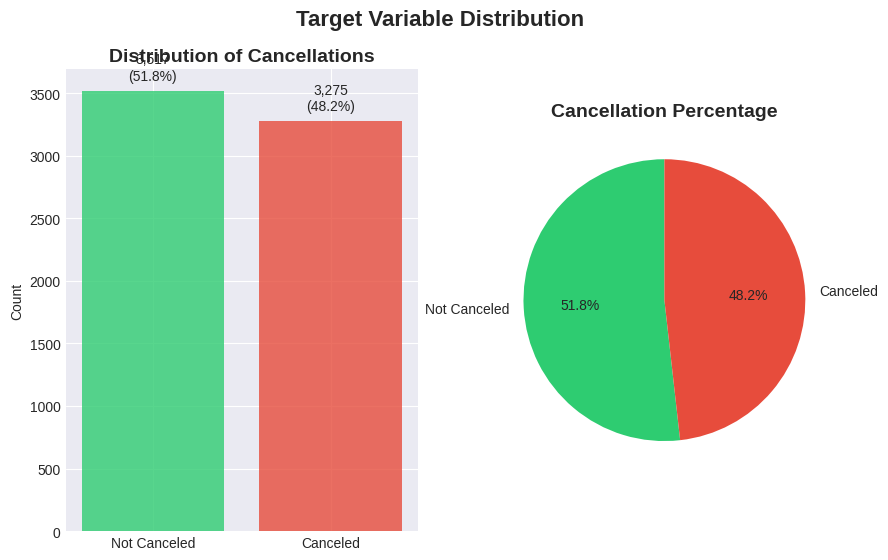

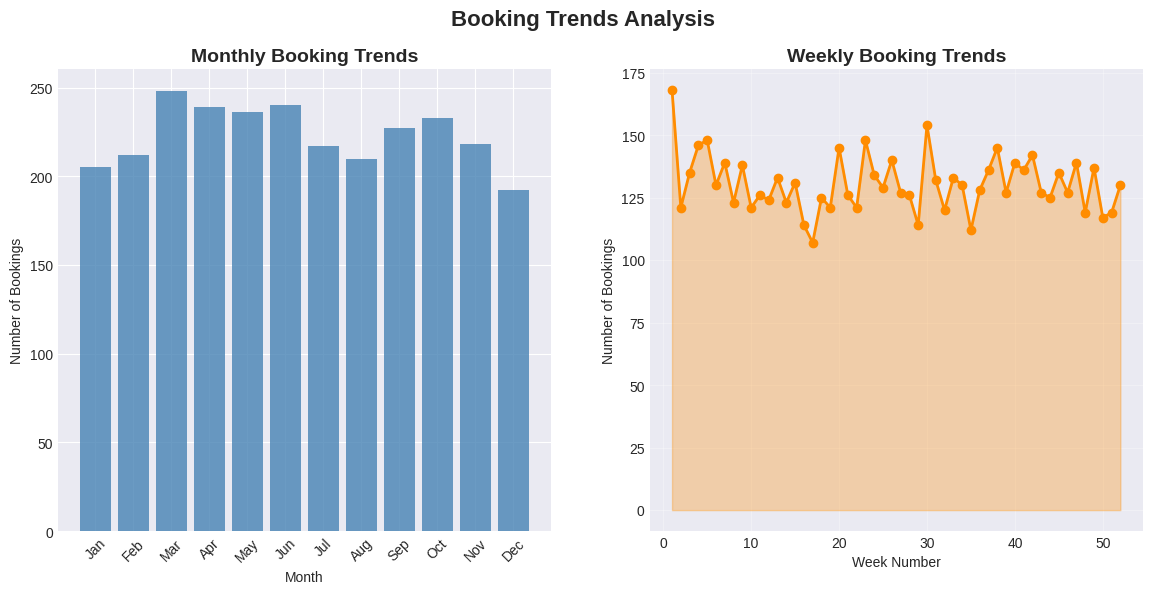

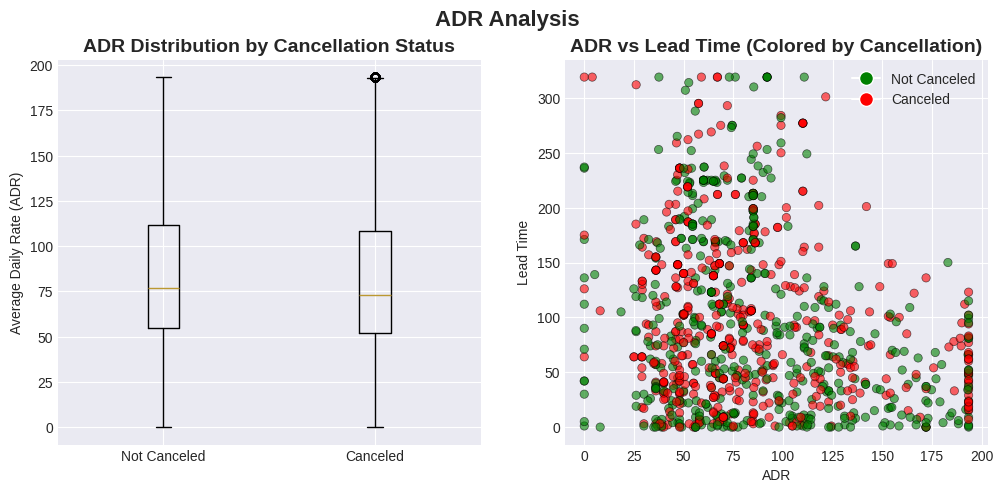

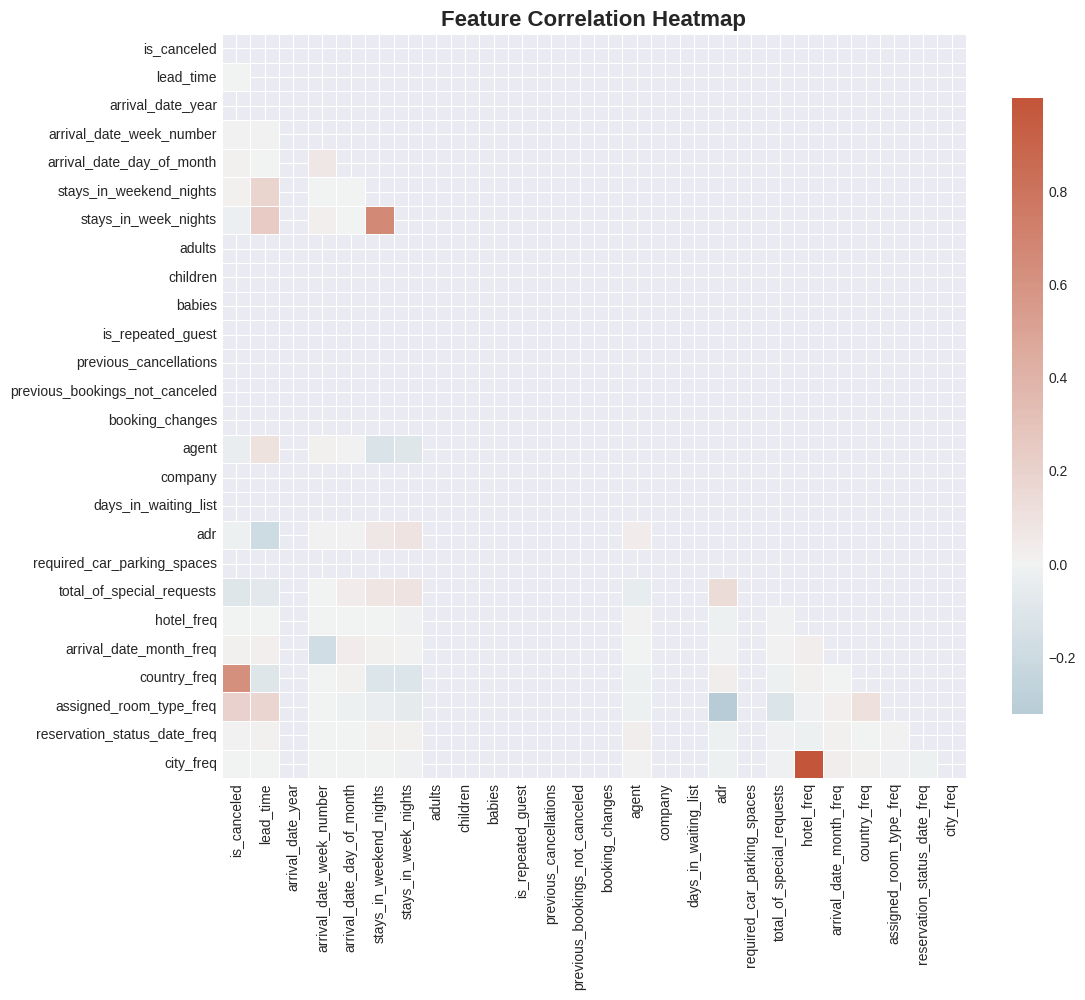

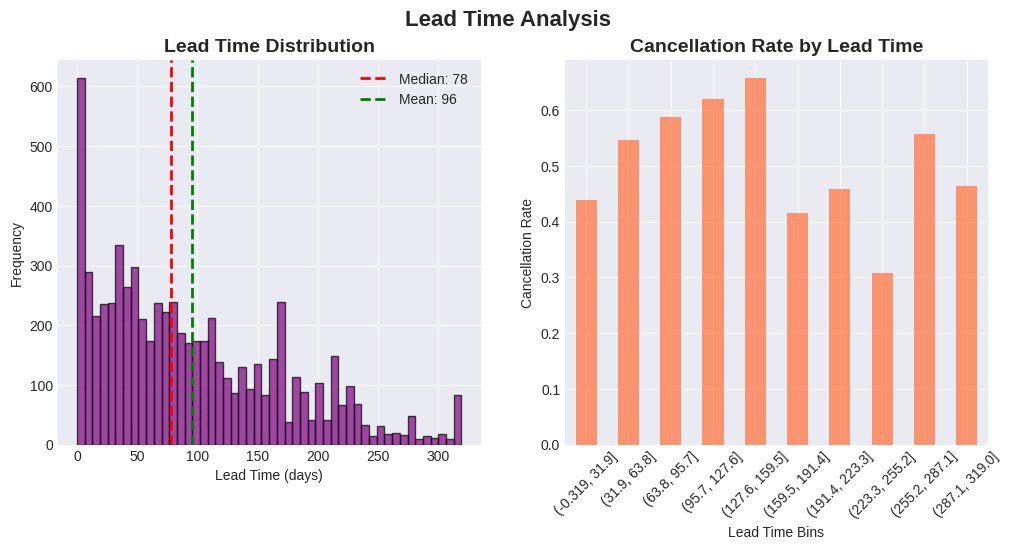

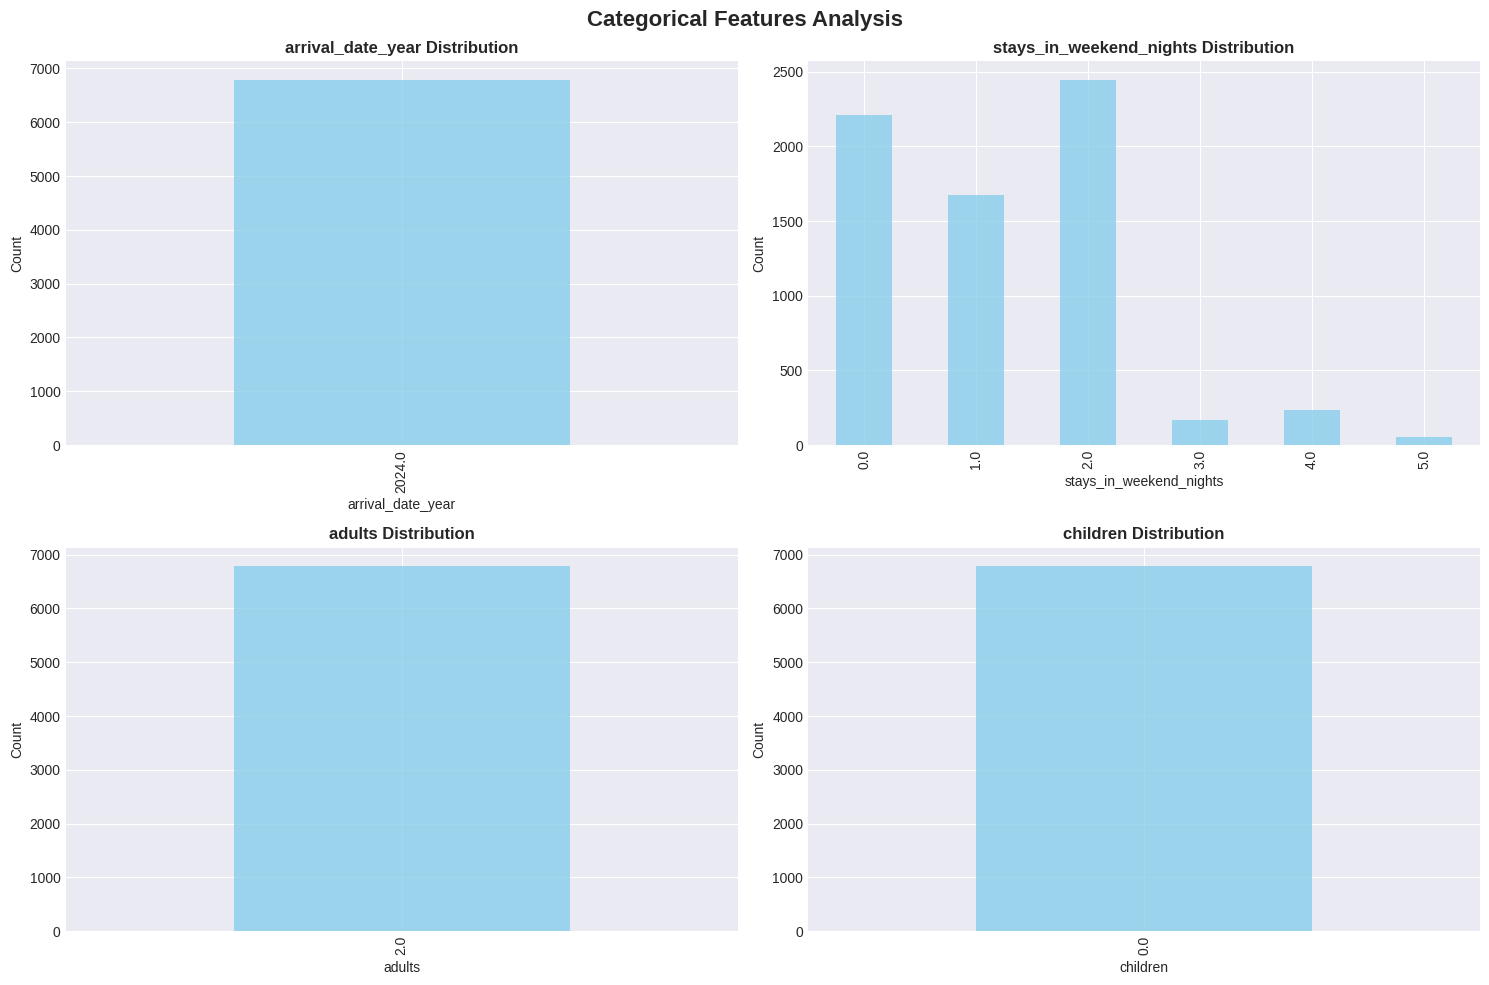


C. CHECKING DATA BALANCE

DATA BALANCE CHECK & HANDLING
Class distribution: {np.int64(0): np.int64(3275), np.int64(1): np.int64(3517)}
Balance ratio (minority/majority): 1.074

Data is imbalanced. Applying undersampling...


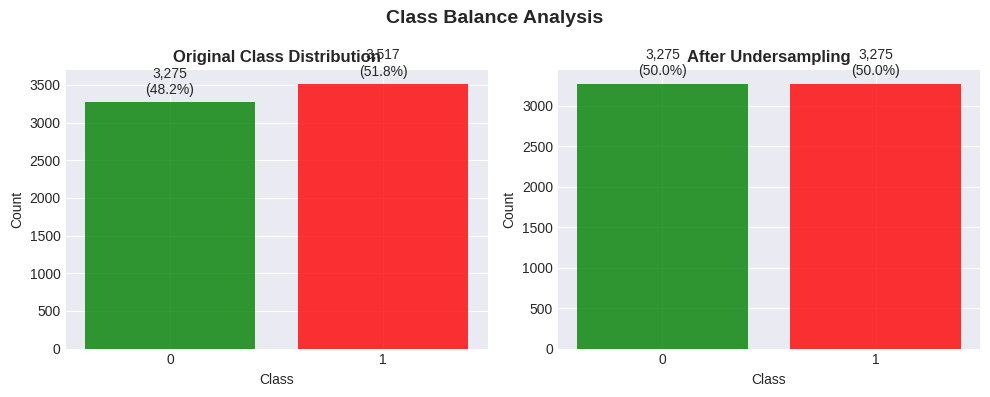


Data shape before balancing: (6792, 52)
Data shape after balancing: (6550, 52)
Balancing method applied: Undersampling

D. FEATURE ENGINEERING

FEATURE ENGINEERING
Created 'total_guests' from ['adults', 'children', 'is_repeated_guest']
Created 'total_stay_nights' from stays_in_weekend_nights and stays_in_week_nights
Created 'season' from arrival_date_day_of_month
Created 'booking_flexibility' from booking_changes
Created 'lead_time_category'
Created 'adr_per_guest'
Dropped constant columns: ['arrival_date_year', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'company', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_guests', 'booking_flexibility']
Dropped some highly correlated features (>0.85)
Dropped irrelevant columns: ['reservation_status_Check-Out', 'reservation_status_No-Show', 'reservation_status_date_freq']
Original features: 53
Engineered features: 40
New features added: ['seaso

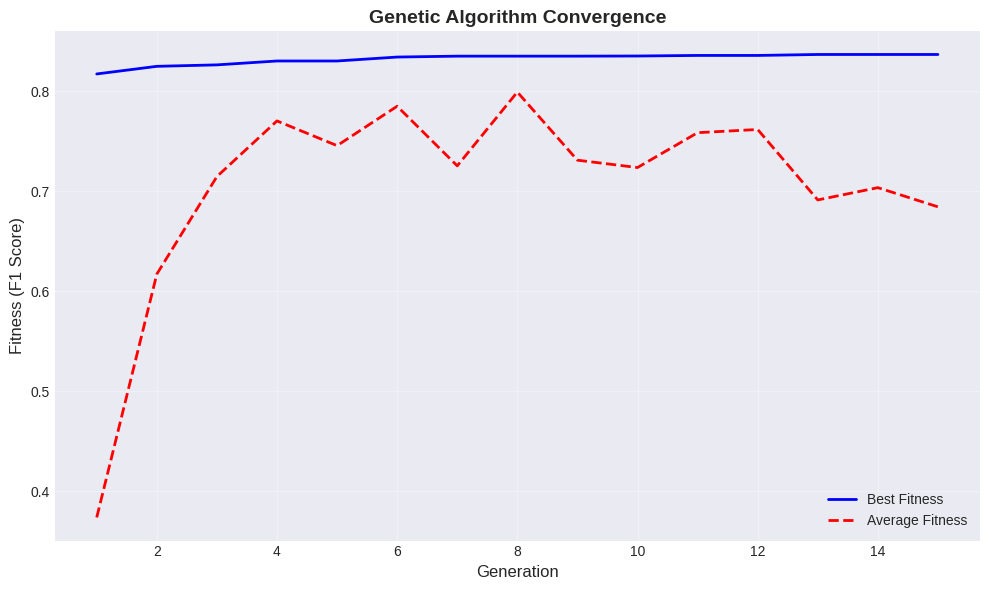


INSIGHT: Genetic Algorithm Convergence
- Shows improvement in feature subset quality over generations
- Best fitness indicates optimal feature subset found
- Convergence pattern indicates algorithm effectiveness

Feature selection completed!
Selected 18 out of 39 features
Selected features: ['lead_time', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'agent', 'total_of_special_requests', 'meal_Undefined', 'market_segment_Online TA', 'distribution_channel_Direct', 'reserved_room_type_D', 'reserved_room_type_E', 'deposit_type_Refundable', 'customer_type_Transient', 'customer_type_Transient-Party', 'arrival_date_month_freq', 'country_freq', 'city_freq', 'total_stay_nights', 'season']

F. MODEL BUILDING & TUNING

Data split:
  Train: (3930, 39) (60.0%)
  Validation: (1310, 39) (20.0%)
  Test: (1310, 39) (20.0%)

MODEL BUILDING & HYPERPARAMETER TUNING

--- Tuning KNN ---
Best parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best validation F1: 0.5440
Va

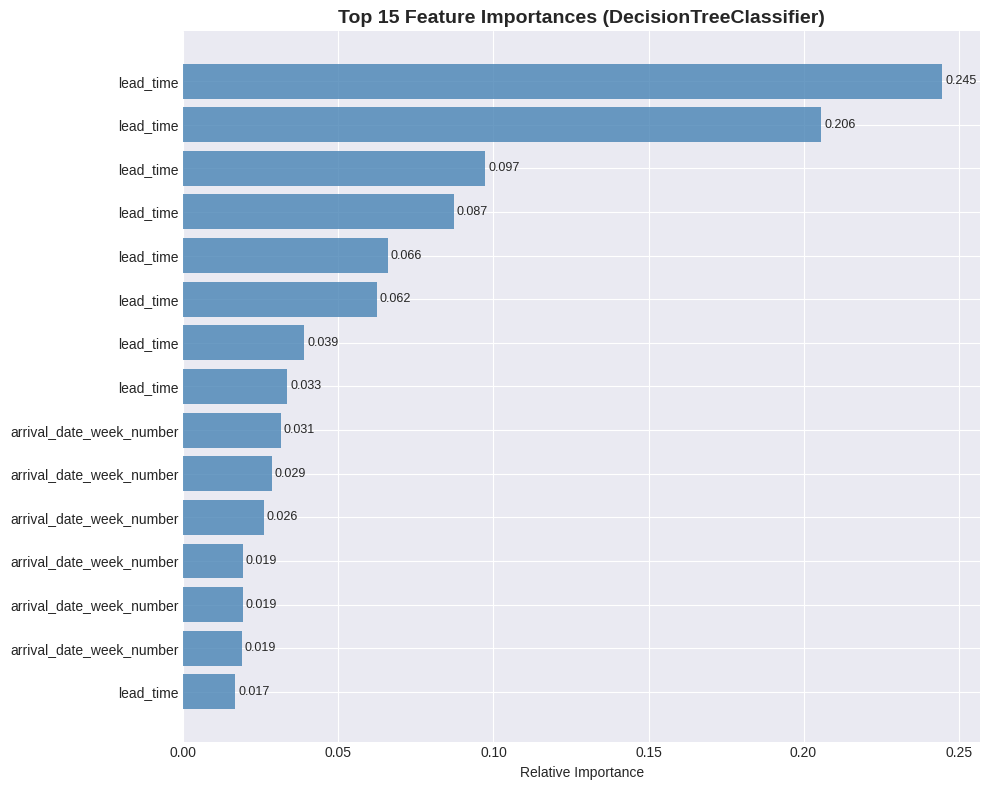


Top 15 most important features:
  lead_time: 0.2447
  lead_time: 0.2057
  lead_time: 0.0973
  lead_time: 0.0872
  lead_time: 0.0659
  lead_time: 0.0623
  lead_time: 0.0389
  lead_time: 0.0335
  arrival_date_week_number: 0.0314
  arrival_date_week_number: 0.0285
  arrival_date_week_number: 0.0259
  arrival_date_week_number: 0.0191
  arrival_date_week_number: 0.0191
  arrival_date_week_number: 0.0188
  lead_time: 0.0166

G. PERFORMANCE EVALUATION

MODEL EVALUATION & COMPARISON

--- Evaluating KNN ---
Accuracy:  0.5435
Precision: 0.5442
Recall:    0.5359
F1-Score:  0.5400
ROC-AUC:   0.5787


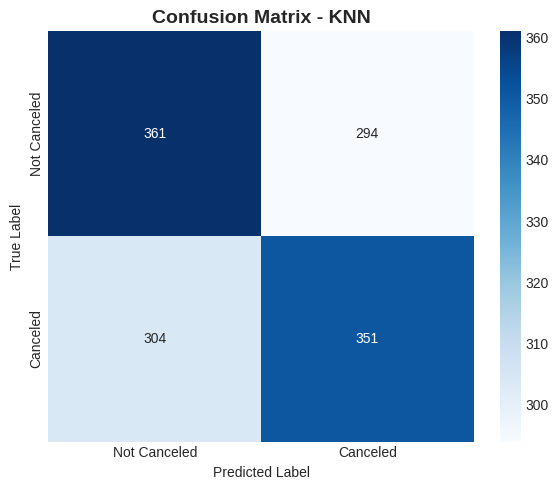

Confusion Matrix Analysis:
  True Negatives: 361  |  False Positives: 294
  False Negatives: 304  |  True Positives: 351
  Specificity: 0.5511

--- Evaluating Decision Tree ---
Accuracy:  0.5947
Precision: 0.6020
Recall:    0.5588
F1-Score:  0.5796
ROC-AUC:   0.6329


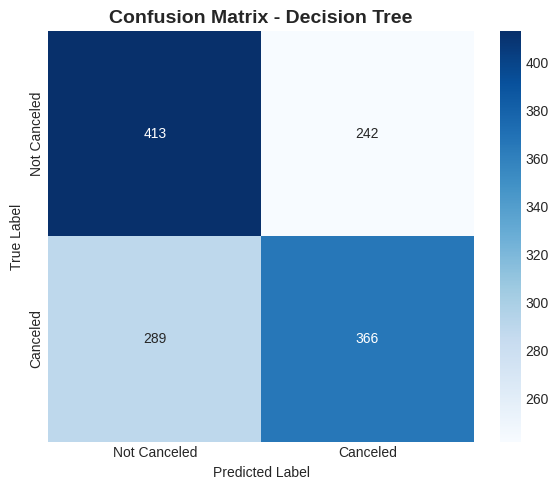

Confusion Matrix Analysis:
  True Negatives: 413  |  False Positives: 242
  False Negatives: 289  |  True Positives: 366
  Specificity: 0.6305

--- Evaluating Neural Network ---
Accuracy:  0.5763
Precision: 0.5774
Recall:    0.5695
F1-Score:  0.5734
ROC-AUC:   0.5967


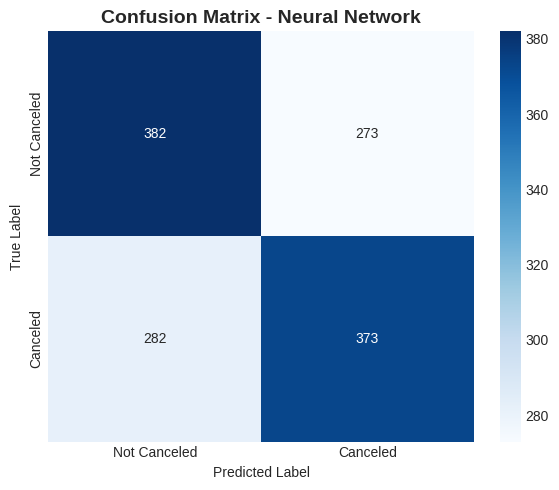

Confusion Matrix Analysis:
  True Negatives: 382  |  False Positives: 273
  False Negatives: 282  |  True Positives: 373
  Specificity: 0.5832


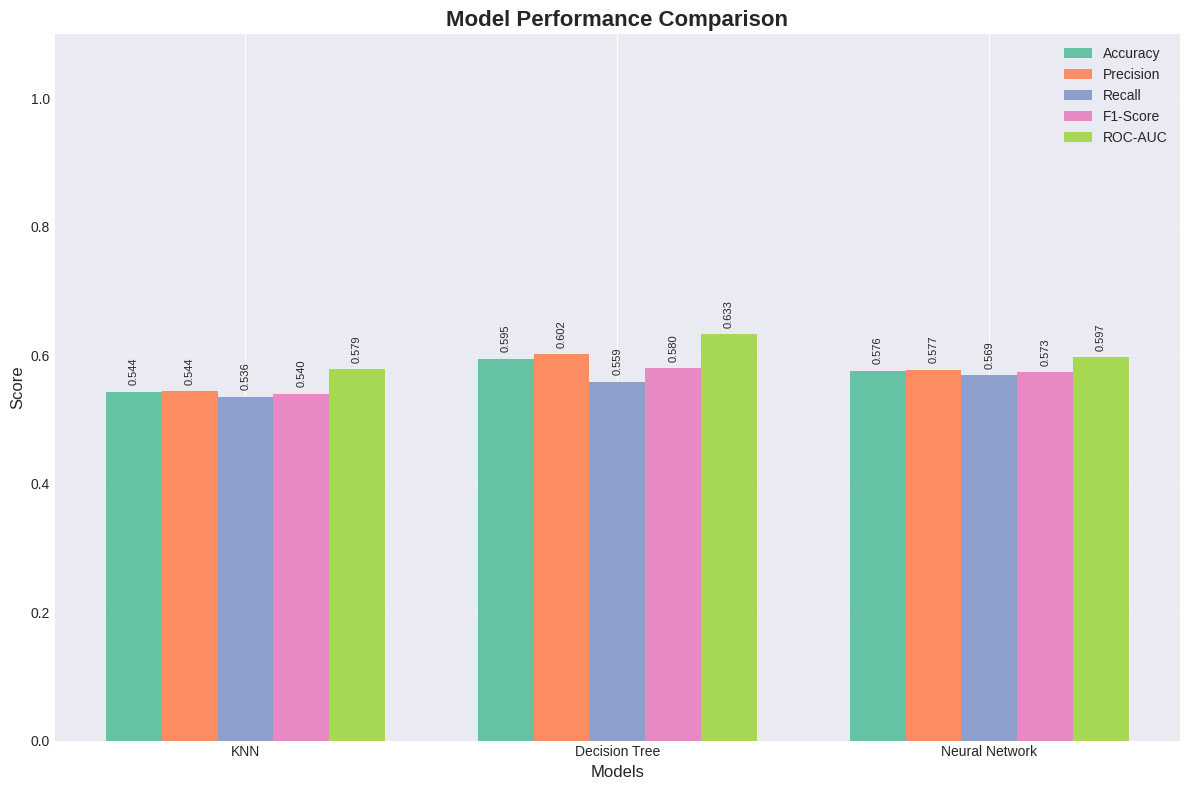


INSIGHT: Model Comparison
- F1-Score balances precision and recall (important for imbalanced data)
- ROC-AUC shows overall ranking capability
- Different models may excel at different metrics

MODEL COMPARISON SUMMARY
                Accuracy  Precision  Recall  F1-Score  ROC-AUC
KNN               0.5435     0.5442  0.5359    0.5400   0.5787
Decision Tree     0.5947     0.6020  0.5588    0.5796   0.6329
Neural Network    0.5763     0.5774  0.5695    0.5734   0.5967

🎯 BEST MODEL: Decision Tree
   F1-Score: 0.5796

FINAL SUMMARY

📊 PIPELINE EXECUTION SUMMARY:
  ✓ A. Data Preprocessing & Cleaning
  ✓ B. Exploratory Data Analysis (EDA)
  ✓ C. Data Balancing: Undersampling
  ✓ D. Feature Engineering
  ✓ E. Feature Selection: 18 features selected via Genetic Algorithm
  ✓ F. Model Building & Tuning (KNN, Decision Tree, Neural Network)
  ✓ G. Performance Evaluation & Comparison

🏆 BEST PERFORMING MODEL:
  Model: Decision Tree
  Accuracy:  0.5947
  Precision: 0.6020
  Recall:    0.5588
  F1-

In [9]:
# ================================
# EXECUTION
# ================================

if __name__ == "__main__":
    # Initialize the predictor
    predictor = HotelBookingPredictor()

    # Print Results
    results = predictor.run_pipeline('/content/hotel_bookings.csv')

    print("\n✅ All tasks completed successfully!")